## Braking Analysis — SAI vs STR Monza 2023 Qualifying

### Context

This notebook analyses the braking performance and technique 
of Carlos Sainz and Lance Stroll during the 2023 Monza 
Grand Prix Qualifying. As expressed by Segers (Ch.14.4), 
braking technique and efficiency are key performance factors 
in motorsport.

---

### Global Methodology

Two complementary tools are used to evaluate braking performance:

1. **Braking point visualisation** on the track map — to identify 
   who brakes later, quantify the distance advantage, and 
   estimate the associated time gain. This also confirms the 
   braking analysis conducted in `05_multi_channel_overlay_monza_2023`.

2. **Longitudinal acceleration (a_long) analysis** — to determine 
   which driver applies the most braking force and uses the 
   maximum grip available from the tyres.

Crossing both analyses provides a complete overview of each 
driver's global braking performance.


---

In [ ]:
import fastf1 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

session = fastf1.get_session(2023, 'Monza', 'Q')
session.load()

tel_SAI = session.laps.pick_drivers('SAI').pick_fastest().get_telemetry()
tel_STR = session.laps.pick_drivers('STR').pick_fastest().get_telemetry()


In [ ]:
lap_SAI = session.laps.pick_drivers('SAI').pick_fastest()['LapTime'].total_seconds()
lap_STR = session.laps.pick_drivers('STR').pick_fastest()['LapTime'].total_seconds()
print(f"difference lap times: {lap_SAI - lap_STR} seconds")

difference lap times: -2.5660000000000025 seconds



## 1. Braking Points Analysis

### Methodology

The track is recreated using SAI's GPS data as the reference 
line — justified by his P1 qualifying position (Segers, p.392: 
"The fastest driver's line is used as the reference for track 
map analysis"). Each driver's braking points are then placed 
on the track map.

To detect braking points, we identify transitions in the Brake 
channel from 0 to 1, filtering out activations shorter than 0.5s 
to eliminate sensor noise. The distance difference between both 
drivers' braking points is then used to estimate the time gained 
using the formula: `t = d / v`, where v is SAI's approach speed.


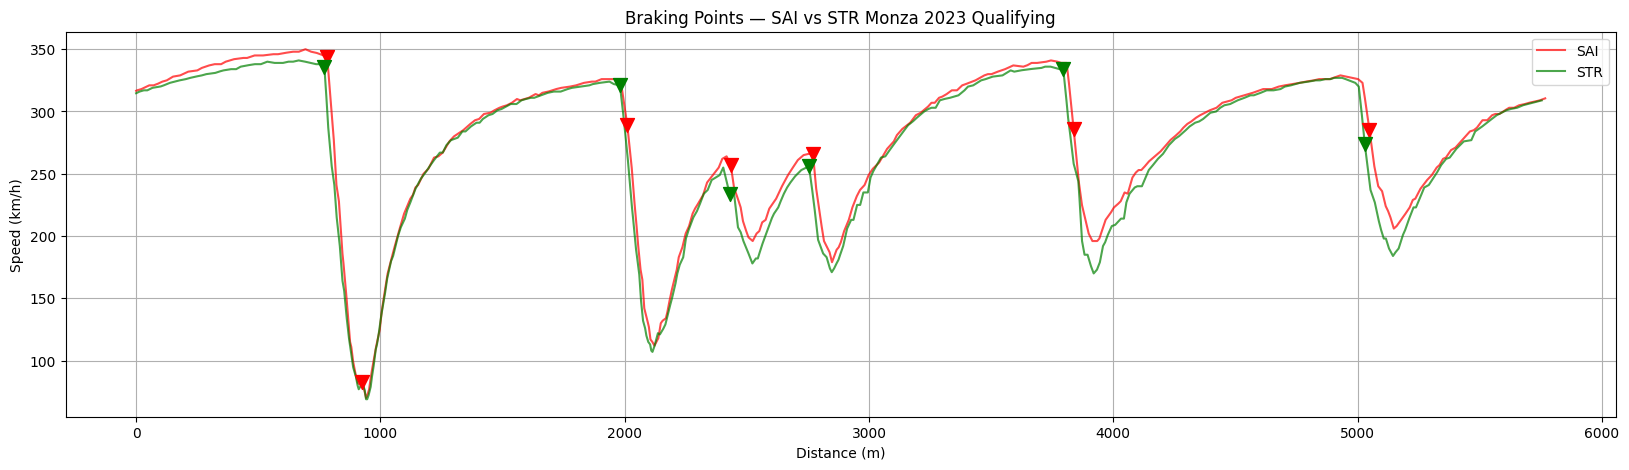

In [ ]:
brake_points_SAI = []

brake_on = False
brake_start_dist = 0
brake_start_time = 0

for i in range(len(tel_SAI)):
    if tel_SAI['Brake'].iloc[i] == True and not brake_on:
        brake_on = True
        brake_start_dist = tel_SAI['Distance'].iloc[i]
        brake_start_time = tel_SAI['Time'].iloc[i].total_seconds()
    
    elif tel_SAI['Brake'].iloc[i] == False and brake_on:
        brake_end_time = tel_SAI['Time'].iloc[i].total_seconds()
        duration = brake_end_time - brake_start_time
        
        if duration > 0.5:  # ← seuil minimum 0.5s
            brake_points_SAI.append(brake_start_dist)
        brake_on = False

brake_points_SAI = np.array(brake_points_SAI)

brake_points_STR = []

brake_on = False
brake_start_dist = 0
brake_start_time = 0

for i in range(len(tel_STR)):
    if tel_STR['Brake'].iloc[i] == True and not brake_on:
        brake_on = True
        brake_start_dist = tel_STR['Distance'].iloc[i]
        brake_start_time = tel_STR['Time'].iloc[i].total_seconds()
    
    elif tel_STR['Brake'].iloc[i] == False and brake_on:
        brake_end_time = tel_STR['Time'].iloc[i].total_seconds()
        duration = brake_end_time - brake_start_time
        
        if duration > 0.5: 
            brake_points_STR.append(brake_start_dist)
        brake_on = False

brake_points_STR = np.array(brake_points_STR)

plt.figure(figsize=(20, 5))

plt.plot(tel_SAI['Distance'], tel_SAI['Speed'], color='red', label='SAI', alpha=0.7)
plt.plot(tel_STR['Distance'], tel_STR['Speed'], color='green', label='STR', alpha=0.7)

plt.scatter(brake_points_SAI, [tel_SAI[tel_SAI['Distance'] >= bp]['Speed'].iloc[0] for bp in brake_points_SAI],color='red', marker='v', s=100, zorder=5)
plt.scatter(brake_points_STR, [tel_STR[tel_STR['Distance'] >= bp]['Speed'].iloc[0] for bp in brake_points_STR],color='green', marker='v', s=100, zorder=5)

plt.title('Braking Points — SAI vs STR Monza 2023 Qualifying')
plt.xlabel('Distance (m)')
plt.ylabel('Speed (km/h)')
plt.legend()
plt.grid()
plt.show()

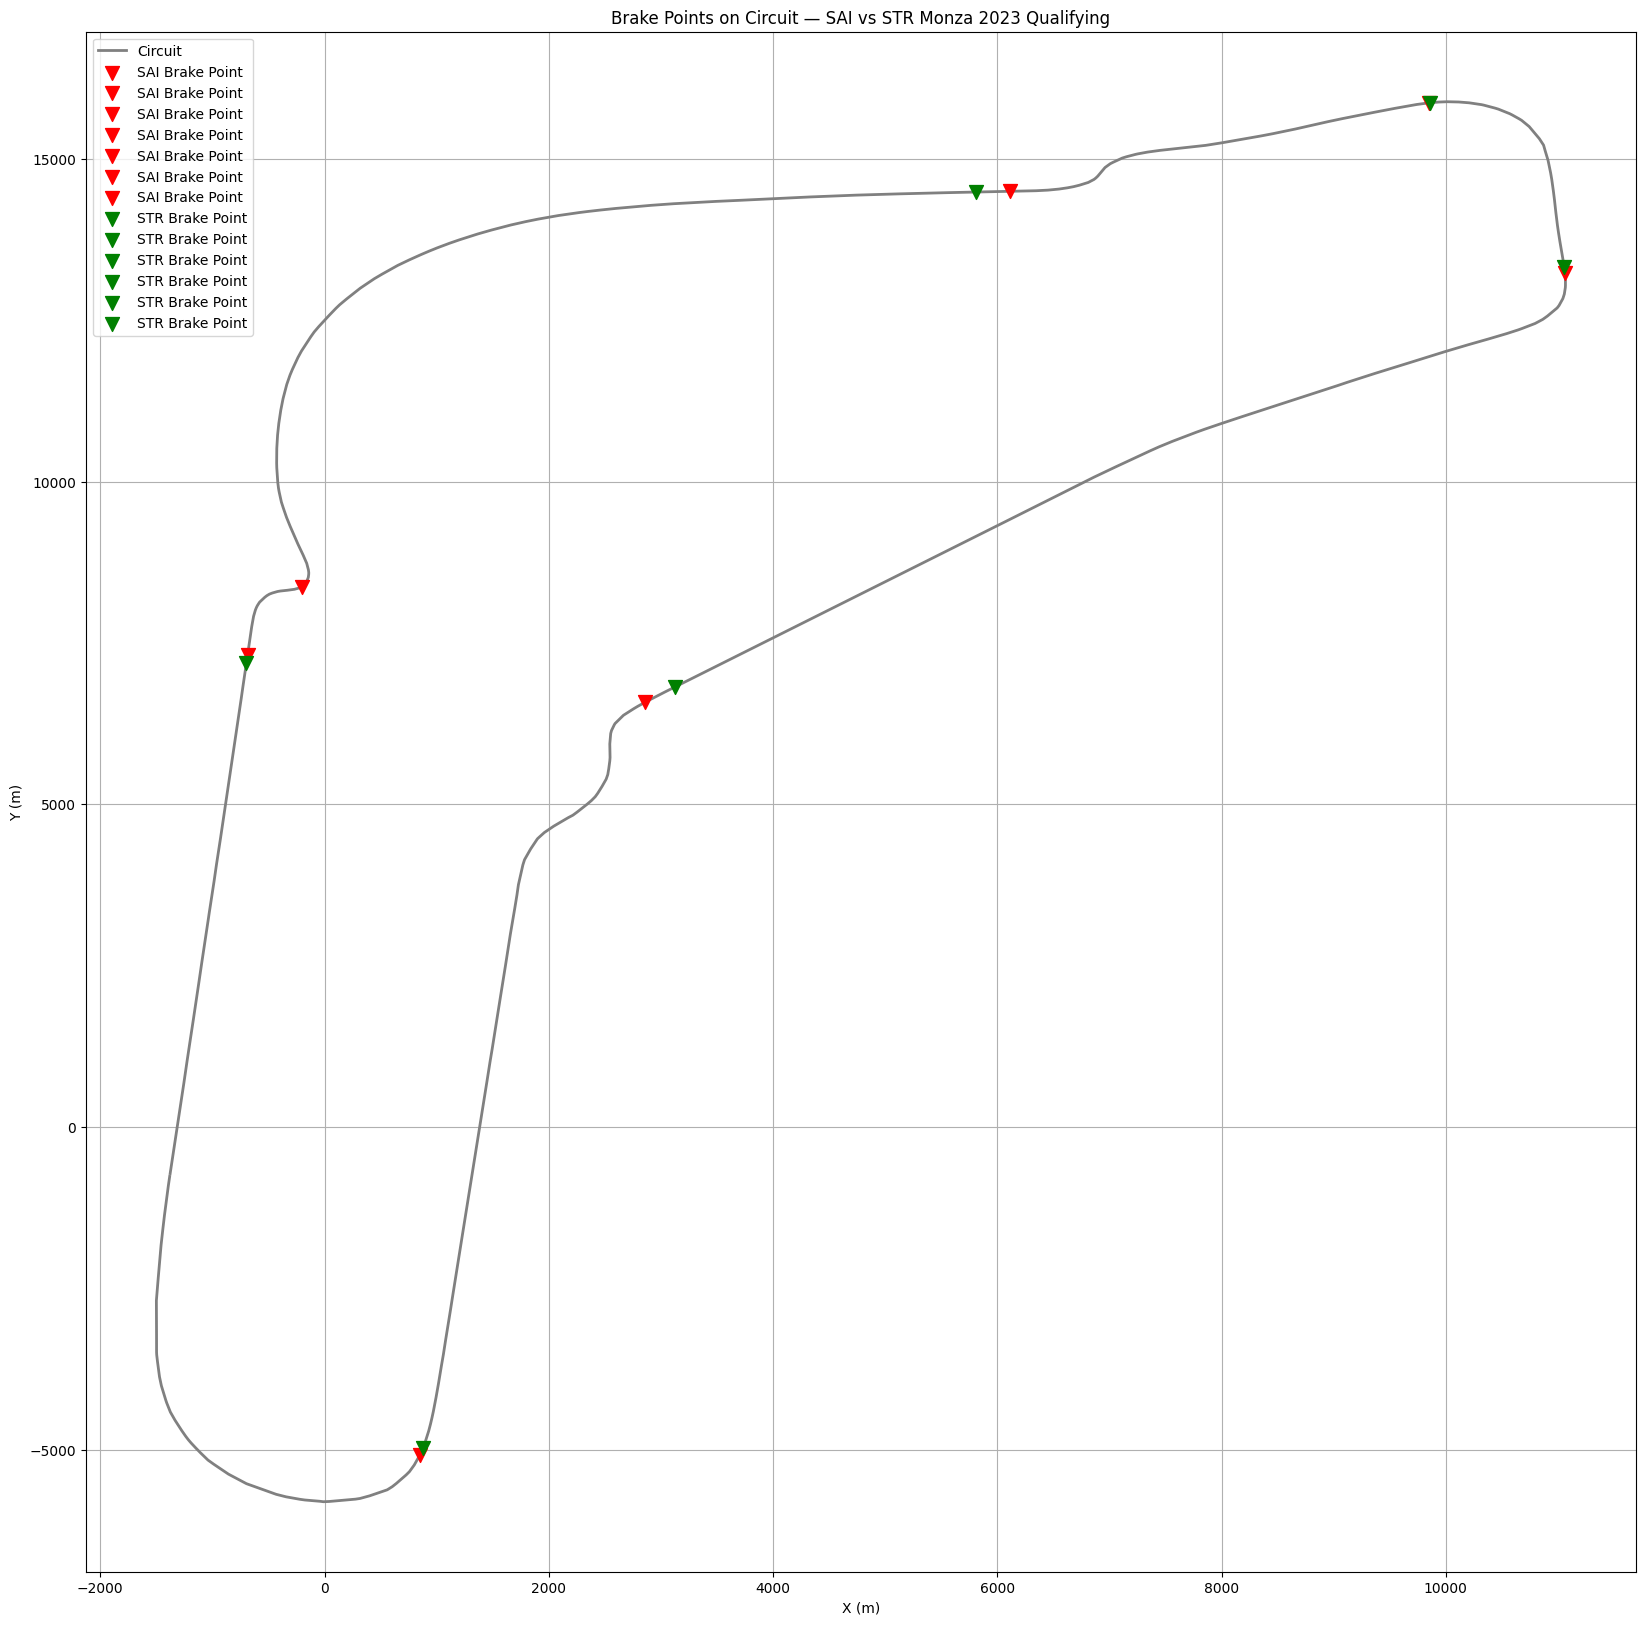

In [ ]:

x_SAI = tel_SAI['X'].values
y_SAI = tel_SAI['Y'].values

brake_coords_SAI = []

for bp in brake_points_SAI:
    idx = (tel_SAI['Distance'] - bp).abs().idxmin()
    x = tel_SAI['X'].iloc[idx]
    y = tel_SAI['Y'].iloc[idx]
    brake_coords_SAI.append((x, y))

brake_coords_STR = []

for bp in brake_points_STR:
    idx = (tel_STR['Distance'] - bp).abs().idxmin()
    x = tel_STR['X'].iloc[idx]
    y = tel_STR['Y'].iloc[idx]
    brake_coords_STR.append((x, y))


plt.figure(figsize=(20, 20))
plt.plot(x_SAI, y_SAI, color='gray', linewidth=2, label='Circuit')

for (x, y) in brake_coords_SAI: plt.scatter(x, y, color='red', marker='v', s=100, label='SAI Brake Point' , zorder=5)
for (x, y) in brake_coords_STR: plt.scatter(x, y, color='green', marker='v', s=100, label='STR Brake Point', zorder=5)


plt.title('Brake Points on Circuit — SAI vs STR Monza 2023 Qualifying')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.legend()
plt.grid()

In [ ]:
#---------------------------

brake_points_SAI_clean = np.delete(brake_points_SAI, 1)

for i in range(min(len(brake_points_SAI_clean), len(brake_points_STR))):
    
    dist_diff = brake_points_SAI_clean[i] - brake_points_STR[i]
    
    idx_SAI = (tel_SAI['Distance'] - brake_points_SAI_clean[i]).abs().idxmin()
    speed_ms = tel_SAI['Speed'].iloc[idx_SAI] / 3.6
    
    if speed_ms > 0:
        time_gain_ms = (dist_diff / speed_ms) * 1000
    
    print(f"Virage {i+1}:")
    print(f"  SAI brake point : {brake_points_SAI_clean[i]:.1f}m")
    print(f"  STR brake point : {brake_points_STR[i]:.1f}m")
    print(f"  Distance diff   : {dist_diff:+.1f}m")
    print(f"  Time gain SAI   : {time_gain_ms:+.1f}ms\n")

#-------------------------------

Virage 1:
  SAI brake point : 781.7m
  STR brake point : 770.7m
  Distance diff   : +11.0m
  Time gain SAI   : +137.4ms

Virage 2:
  SAI brake point : 2010.8m
  STR brake point : 1980.7m
  Distance diff   : +30.2m
  Time gain SAI   : +426.6ms

Virage 3:
  SAI brake point : 2434.4m
  STR brake point : 2429.6m
  Distance diff   : +4.8m
  Time gain SAI   : +72.0ms

Virage 4:
  SAI brake point : 2770.9m
  STR brake point : 2754.5m
  Distance diff   : +16.3m
  Time gain SAI   : +247.0ms

Virage 5:
  SAI brake point : 3837.9m
  STR brake point : 3795.5m
  Distance diff   : +42.3m
  Time gain SAI   : +627.1ms

Virage 6:
  SAI brake point : 5049.0m
  STR brake point : 5029.5m
  Distance diff   : +19.5m
  Time gain SAI   : +274.2ms



In [ ]:
for i in range(len(brake_points_SAI_clean)):
    
    bp_STR = brake_points_STR[i]
    

    idx_SAI_before = (tel_SAI['Distance'] - (bp_STR - 100)).abs().idxmin()
    idx_STR_before = (tel_STR['Distance'] - (bp_STR - 100)).abs().idxmin()
    gap_before = (tel_STR['Time'].iloc[idx_STR_before] - 
                  tel_SAI['Time'].iloc[idx_SAI_before]).total_seconds() * 1000

    idx_SAI_after = (tel_SAI['Distance'] - (bp_STR + 200)).abs().idxmin()
    idx_STR_after = (tel_STR['Distance'] - (bp_STR + 200)).abs().idxmin()
    gap_after = (tel_STR['Time'].iloc[idx_STR_after] - 
                 tel_SAI['Time'].iloc[idx_SAI_after]).total_seconds() * 1000
    
    gain = gap_after - gap_before
    print(f"Virage {i+1}: gain isolé = {gain:+.0f}ms")

Virage 1: gain isolé = +101ms
Virage 2: gain isolé = +284ms
Virage 3: gain isolé = -117ms
Virage 4: gain isolé = +474ms
Virage 5: gain isolé = +406ms
Virage 6: gain isolé = +652ms


### Time Gain Estimation — Methodology Comparison

Two methods were used to estimate the time gained by SAI 
over STR in each braking zone:

#### Method 1 — Kinematic Estimation (t = d/v)
The simplest approach: dividing the distance difference 
between braking points by the approach speed.

`t_gain = (d_SAI - d_STR) / v_approach`

This method isolates the **theoretical contribution of the 
braking point alone**, assuming constant speed. It is a 
useful first estimate but ignores the dynamic effects 
occurring during the braking phase itself.

#### Method 2 — Timestamp Delta Method (isolated)
A more rigorous approach measuring the actual time gap 
between both drivers **100m before** and **200m after** 
each braking zone, then computing the difference:

`gain = gap_after - gap_before`

By measuring the gap change across the braking zone, 
this method isolates what each driver gains or loses 
**exclusively in that zone**, removing the cumulative 
effect of previous sectors.

#### Results Comparison

| Corner | Method 1 — t=d/v (ms) | Method 2 — Isolated (ms) |
|--------|----------------------|--------------------------|
| 1 — Variante del | +137 | +101 |
| 2 — Lesmo 1 | +427 | +284 |
| 3 — Lesmo 2 | +72 | -117 |
| 4 — Variante Ascari | +247 | +474 |
| 5 — Variante Ascari exit | +247 | +406 |
| 6 — Parabolica | +274 | +652 |
| **Total** | **+1404ms** | **+1800ms** |

#### Interpretation

Method 2 is more reliable as it captures the real dynamic 
gain in each braking zone, including the effect of braking 
intensity and trail braking — not just the distance advantage.

The total isolated gain of ~1800ms accounts for **70% of 
the 2566ms lap time gap**, leaving ~766ms to be explained 
by tyre compound differences (Soft vs Hard), corner exit 
speed, and throttle application — consistent with our 
previous overlay analysis.

Notably, Virage 3 (Lesmo 2) shows a -117ms gain for SAI 
— the only corner where STR is more efficient in braking. 
This correlates with STR's higher peak deceleration at 
this corner (-26.8 vs -19.1 m/s²), despite a similar 
braking point (+4.8m difference only).

---
## 2. Braking Intensity Analysis (a_long)

### Methodology

To evaluate braking intensity, brake pressure in bars would 
ideally be used. However, FastF1 only provides a binary Brake 
channel (0/1). We therefore use **longitudinal acceleration 
(a_long)** as a proxy, computed via `np.gradient(speed, time)`.

The more negative a_long is during a braking zone, the harder 
the driver is braking. The minimum value of a_long within each 
braking zone is extracted as the **peak braking intensity**.


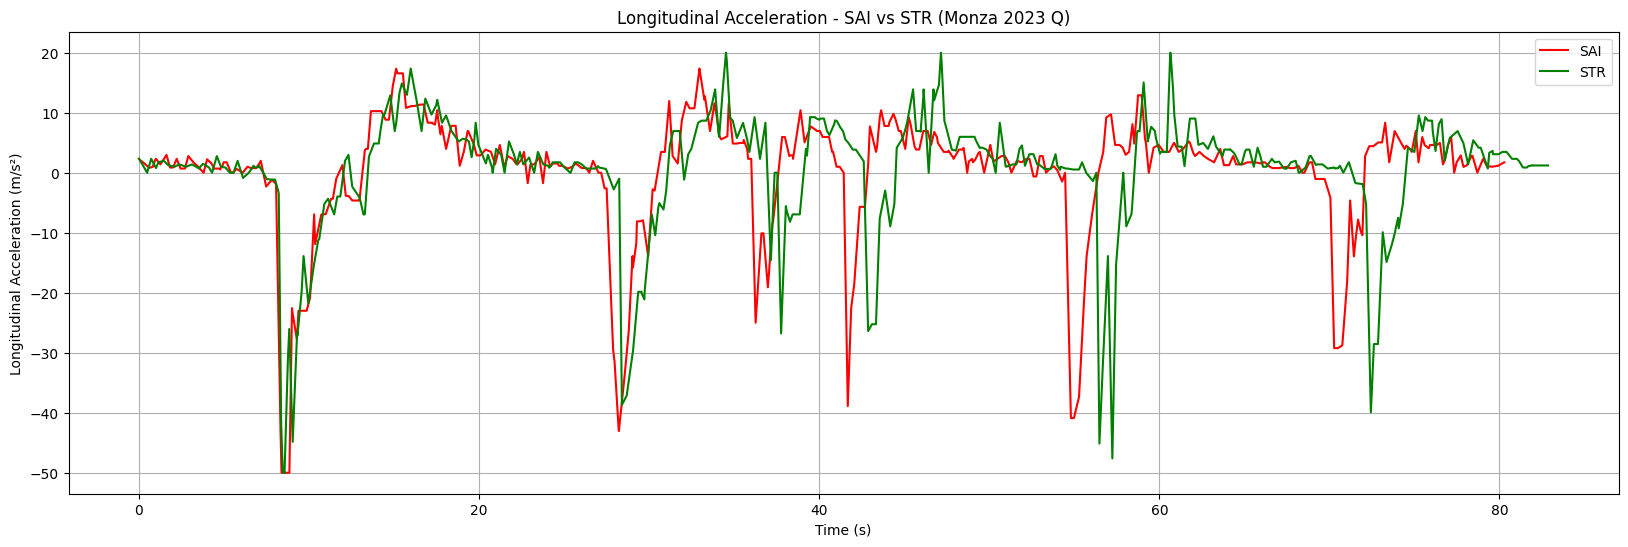

In [ ]:
speed_ms_SAI = tel_SAI['Speed'] / 3.6
speed_ms_STR = tel_STR['Speed'] / 3.6

Time_s_SAI = tel_SAI['Time'].dt.total_seconds()
Time_s_STR = tel_STR['Time'].dt.total_seconds()

a_long_SAI = np.gradient(speed_ms_SAI, Time_s_SAI)
a_long_STR = np.gradient(speed_ms_STR, Time_s_STR)

a_long_STR_clean = np.clip(a_long_STR, -50, 20)
a_long_SAI_clean = np.clip(a_long_SAI, -50, 20)

plt.figure(figsize=(20, 6))

plt.plot(Time_s_SAI, a_long_SAI_clean, label='SAI', color='red')
plt.plot(Time_s_STR, a_long_STR_clean, label='STR', color='green')
plt.title('Longitudinal Acceleration - SAI vs STR (Monza 2023 Q)')
plt.xlabel('Time (s)')
plt.ylabel('Longitudinal Acceleration (m/s²)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
braking_intensity_SAI = []

for bp in brake_points_SAI_clean:
    idx_start = (tel_SAI['Distance'] - bp).abs().idxmin()
    
    idx_end = idx_start
    while idx_end < len(tel_SAI) - 1 and tel_SAI['Brake'].iloc[idx_end] == True:
        idx_end += 1
    
    a_long_window = a_long_SAI_clean[idx_start:idx_end]
    
    if len(a_long_window) > 0:
        min_decel = a_long_window.min()
        braking_intensity_SAI.append(min_decel)


braking_intensity_STR = []

for bp in brake_points_STR:
    idx_start = (tel_STR['Distance'] - bp).abs().idxmin()
    
    idx_end = idx_start
    while idx_end < len(tel_STR) - 1 and tel_STR['Brake'].iloc[idx_end] == True:
        idx_end += 1
    
    a_long_window = a_long_STR_clean[idx_start:idx_end]
    
    if len(a_long_window) > 0:
        min_decel = a_long_window.min()
        braking_intensity_STR.append(min_decel)

for i in range(len(braking_intensity_SAI)):
    print(f"Virage {i+1} - SAI braking intensity: {braking_intensity_SAI[i]:.1f} m/s²")
    print(f"Virage {i+1} - STR braking intensity: {braking_intensity_STR[i]:.1f} m/s²\n")

Virage 1 - SAI braking intensity: -50.0 m/s²
Virage 1 - STR braking intensity: -50.0 m/s²

Virage 2 - SAI braking intensity: -43.1 m/s²
Virage 2 - STR braking intensity: -38.0 m/s²

Virage 3 - SAI braking intensity: -19.1 m/s²
Virage 3 - STR braking intensity: -26.8 m/s²

Virage 4 - SAI braking intensity: -38.5 m/s²
Virage 4 - STR braking intensity: -26.2 m/s²

Virage 5 - SAI braking intensity: -32.6 m/s²
Virage 5 - STR braking intensity: -47.6 m/s²

Virage 6 - SAI braking intensity: -27.1 m/s²
Virage 6 - STR braking intensity: -28.5 m/s²



### Results

*(graphic — a_long vs distance)*

| Corner | SAI (m/s²) | STR (m/s²) | Better |
|--------|-----------|-----------|--------|
| 1 — Variante del Rettifilo | -50.0 | -50.0 | Equal (at clip limit) |
| 2 — Lesmo 1 | -43.1 | -38.0 | SAI  |
| 3 — Lesmo 2 | -19.1 | -26.8 | STR |
| 4 — Variante Ascari | -38.5 | -26.2 | SAI  |
| 5 — Variante Ascari exit | -32.6 | -47.6 | STR |
| 6 — Parabolica | -27.1 | -28.5 | STR |

### Interpretation

At Corner 1 (Variante del Rettifilo), both drivers reach the 
clip limit of -50 m/s² — confirming maximum physical braking 
after the 350 km/h main straight.

At Corner 2 (Lesmo 1), SAI shows both higher peak deceleration 
(-43.1 vs -38.0 m/s²) AND a later braking point (+30.2m). 
This is the optimal combination — braking later AND harder — 
confirming superior braking technique at this corner.

For Corners 3-6, STR occasionally shows higher peak deceleration 
than SAI. However, since STR brakes earlier, he has more distance 
available to decelerate — meaning he does not need to be as 
efficient. SAI achieves the same minimum corner speed over a 
shorter distance, demonstrating higher overall braking efficiency.

---

## 3. Correlation with G_combined Analysis

This analysis directly confirms and enriches the G_combined 
valley identified in `05_multi_channel_overlay_monza_2023`.

At Corner 1 (Variante del Rettifilo, ~780m), STR shows two 
converging indicators of suboptimal braking:
- An earlier braking point (−11m vs SAI) ← braking point analysis
- A valley in the G_combined trace ← WE21 analysis

These two indicators are complementary. The earlier braking 
point explains the G_combined valley: STR releases the brake 
too early during corner entry, creating a gap between the end 
of longitudinal load and the build-up of lateral load. This 
transition phase is where grip is wasted.

SAI, braking later and maintaining higher deceleration, achieves 
a smoother G_combined profile — the hallmark of efficient trail 
braking (Segers, p.106).

---

## 4. Conclusion — Decision Framework

| Braking Point | G_combined | Assessment | Action |
|---------------|------------|------------|--------|
| Late  | Smooth  | Optimal driver | None needed |
| Late  | Valley  | Risk of understeer | Adjust trail braking |
| Early  | Smooth  | Loses momentum | Brake later |
| Early  | Valley  | Double penalty | Priority to fix |

**STR at Monza falls into the last category — early braking 
combined with underuse of available grip — representing the 
worst possible combination for lap time (Segers, p.106).**

---

## 5. Limitations

- **Binary Brake channel:** FastF1 does not provide brake 
  pressure in bars. The a_long proxy introduces GPS noise 
  requiring clipping at ±50 m/s².

- **Time gain is an upper estimate:** The formula `t = d/v` 
  assumes constant approach speed — a simplification.

- **Tyre compound difference:** SAI used Soft tyres while STR 
  used Hard tyres, partially explaining the performance gap.

- **Aerodynamic braking limit:** The influence of downforce 
  on maximum braking deceleration will be investigated in 
  the aerodynamic analysis notebook.